In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("df_final_final.csv")

df.head()

,name,title,context,date,year,full_text,cleaned_tokens,text_length,token_count,cleaned_tokens_no_name,token_count_no_name,cleaned_tokens_final,token_count_final,cleaned_tokens_analysis,token_count_analysis
0,메모러블모먼트,"둔촌동역카페 메모러블모먼트 메뉴 추천, 강동구 블루리본카페 올림픽공원카페 후기",메모러블모먼트 ✔️서울 강동구 양재대로 83길 14 ✔️5호선 둔촌동역 3번 출구에...,2주 전,2026,"둔촌동역카페 메모러블모먼트 메뉴 추천, 강동구 블루리본카페 올림픽공원카페 후기 메모...",둔촌동역 메모 러블 모먼트 메뉴 블루리본 올림픽 공원 메모 러블 모먼트 양재대로 호...,262,36,둔촌동역 메뉴 블루리본 올림픽 공원 양재대로 호선 둔촌동역 출구 영업 시간 블루리본...,27,둔촌동역 메뉴 블루리본 올림픽 공원 양재대로 둔촌동역 출구 블루리본 맛집 주차 공간...,23,메뉴 블루리본 블루리본 공간 협소 한살림 유료 도보 블루리본 우연히,10
1,메모러블모먼트,강동구 분위기 좋은 카페 메모러블모먼트 블루리본 디저트 솔직 후기,특히 아몬드가 인상적이어서 디저트 메뉴를 함께 즐기기 좋은 곳이었다. 분위기도 조용...,2026.03.22.,2026,강동구 분위기 좋은 카페 메모러블모먼트 블루리본 디저트 솔직 후기 특히 아몬드가 인...,분위기 좋다 메모 러블 모먼트 블루리본 디저트 솔직 아몬드 인상 디저트 메뉴 함께 ...,198,32,분위기 좋다 블루리본 디저트 솔직 아몬드 인상 디저트 메뉴 함께 좋다 분위기 조용하...,26,분위기 좋다 블루리본 디저트 솔직 아몬드 인상 디저트 메뉴 좋다 분위기 조용하다 깔...,25,분위기 좋다 블루리본 디저트 솔직 아몬드 인상 디저트 메뉴 좋다 분위기 조용하다 깔...,24
2,메모러블모먼트,올림픽공원 근처 둔촌동 카페 메모러블모먼트 Memorable Moment 후기,내돈내산 둔촌동 카페 메모러블 모먼트 방문 후기. 메모러블 모먼트라는 카페에 다녀왔...,2026.07.10.,2026,올림픽공원 근처 둔촌동 카페 메모러블모먼트 Memorable Moment 후기 내돈...,올림픽 공원 근처 메모 러블 모먼트 메모 러블 모먼트 메모 러블 모먼트 골목 국민 ...,241,38,올림픽 공원 근처 골목 국민 떡볶이 같다 건물 주차장 따로 없다 올림픽 공원 가깝다...,26,올림픽 공원 골목 국민 떡볶이 건물 주차장 따로 올림픽 공원 가깝다 저희 올림픽 공...,20,국민 떡볶이 따로 가깝다 저희 산책 프랜차이즈 손님 생각,9
3,메모러블모먼트,[둔촌동 카페]메모러블모먼트 | 블루리본 받은 분위기 좋은 카페,메모러블모먼트 서울 강동구 성내동 440-25 월-금 8:30-23:00 토일 8:...,2026.08.01.,2026,[둔촌동 카페]메모러블모먼트 | 블루리본 받은 분위기 좋은 카페 메모러블모먼트 서울...,메모 러블 모먼트 블루리본 분위기 좋다 메모 러블 모먼트 토일 라스트 마감 안녕하다...,252,35,블루리본 분위기 좋다 토일 라스트 마감 안녕하다 루시 이다 근처 우연히 발견 블루리...,29,블루리본 분위기 좋다 토일 라스트 마감 루시 우연히 발견 블루리본 메뉴 생각 다양하...,22,블루리본 분위기 좋다 토일 라스트 마감 루시 우연히 발견 블루리본 메뉴 생각 다양하...,22
4,메모러블모먼트,"[강동구 카페] 찰나의 순간이 기록되는 곳, 메모러블모먼트(Memorable Mom...",강동구에서 이미 감성 카페로 입소문이 자자한 '메모러블모먼트'입니다. 저는 참새가 ...,2026.04.11.,2026,"[강동구 카페] 찰나의 순간이 기록되는 곳, 메모러블모먼트(Memorable Mom...",찰나 순간 기록 메모 러블 모먼트 솔직 이미 감성 소문 자자하다 메모 러블 모먼트 ...,270,43,찰나 순간 기록 솔직 이미 감성 소문 자자하다 이다 참새 방앗간 근처 무조건 이다 ...,37,찰나 순간 기록 솔직 이미 감성 소문 자자하다 참새 방앗간 무조건 양재대로 강동역 ...,29,찰나 순간 기록 솔직 이미 감성 소문 자자하다 참새 방앗간 특징 블루리본 베이 연속...,24


In [4]:
df[['name', 'cleaned_tokens_analysis']].head()

,name,cleaned_tokens_analysis
0,메모러블모먼트,메뉴 블루리본 블루리본 공간 협소 한살림 유료 도보 블루리본 우연히
1,메모러블모먼트,분위기 좋다 블루리본 디저트 솔직 아몬드 인상 디저트 메뉴 좋다 분위기 조용하다 깔...
2,메모러블모먼트,국민 떡볶이 따로 가깝다 저희 산책 프랜차이즈 손님 생각
3,메모러블모먼트,블루리본 분위기 좋다 토일 라스트 마감 루시 우연히 발견 블루리본 메뉴 생각 다양하...
4,메모러블모먼트,찰나 순간 기록 솔직 이미 감성 소문 자자하다 참새 방앗간 특징 블루리본 베이 연속...


In [5]:
df['cleaned_tokens_analysis'].isnull().sum()

np.int64(0)

In [7]:
df['cleaned_tokens_analysis'] = (
    df['cleaned_tokens_analysis']
    .fillna('')
    .astype(str)
)

In [8]:
tfidf_vectorizer = TfidfVectorizer(
    tokenizer=str.split,
    token_pattern=None,
    min_df=5, #희소 단어 제거(5개 미만 등장)
    max_df=0.8 #과다 리뷰 제거(80% 이상 등장)
)

In [9]:
#행렬 생성
tfidf_matrix = tfidf_vectorizer.fit_transform(
    df['cleaned_tokens_analysis']
)

print(tfidf_matrix.shape)

(5037, 3224)


In [10]:
#평균 TF-IDF 계산
feature_names = tfidf_vectorizer.get_feature_names_out()

tfidf_scores = np.asarray(
    tfidf_matrix.mean(axis=0)
).flatten()

In [11]:
tfidf_df = pd.DataFrame({
    'word': feature_names,
    'tfidf_score': tfidf_scores
})

tfidf_df = tfidf_df.sort_values(
    'tfidf_score',
    ascending=False
)

tfidf_df.head(20)

,word,tfidf_score
677,디저트,0.036862
2446,좋다,0.034131
2753,커피,0.031735
1131,베이커리,0.028459
847,맛있다,0.028122
1229,분위기,0.023482
1865,에그타르트,0.020951
1247,브런치,0.020232
1307,빵집,0.019920
892,메뉴,0.016856


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
# 나눔 고딕 폰트 설치
%cd /content
!wget https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = 'NanumGothic-Regular.ttf'       # 설치한 폰트 경로
fm.fontManager.addfont(font_path)   # 폰트 경로 추가

plt.rcParams['font.family'] = 'NanumGothic' # 사용 폰트 입력
plt.rcParams['axes.unicode_minus'] = False  # 음수 부호 사용

/content
--2026-09-09 01:10:56--  https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/google/fonts/main/ofl/nanumgothic/NanumGothic-Regular.ttf [following]
--2026-09-09 01:10:56--  https://raw.githubusercontent.com/google/fonts/main/ofl/nanumgothic/NanumGothic-Regular.ttf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2054744 (2.0M) [application/octet-stream]
Saving to: ‘NanumGothic-Regular.ttf’

NanumGothic-Regular 100%[===================>]   1.96M  --.-KB/s    in 0.06s   

2026-09-09 01:10:56 (32.3 MB/s) - ‘NanumGot

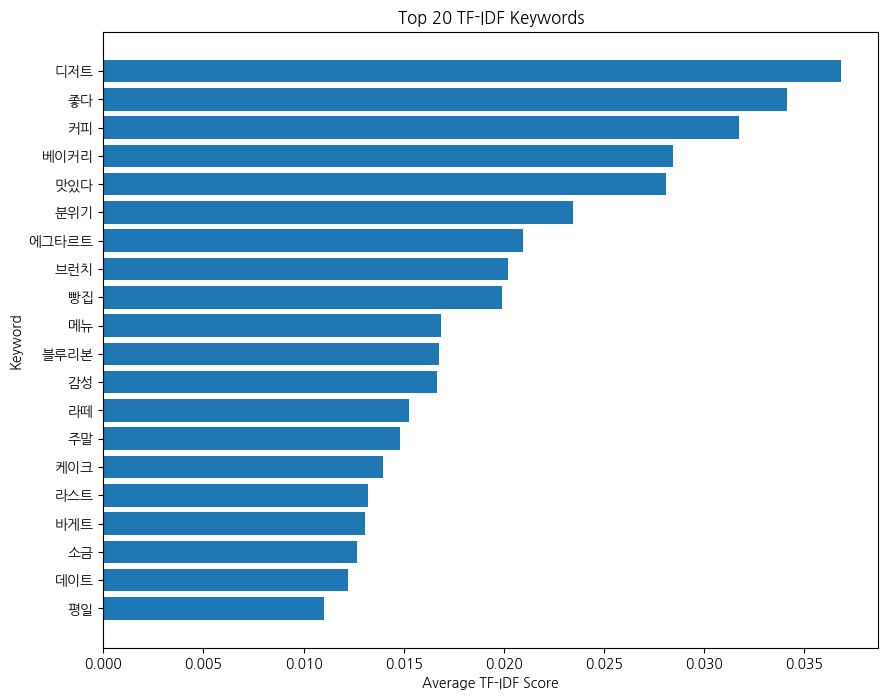

In [14]:
#TOP20 시각화
top_n = 20

top_words = tfidf_df.head(top_n).sort_values(
    'tfidf_score'
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_words['word'],
    top_words['tfidf_score']
)

plt.title('Top 20 TF-IDF Keywords')
plt.xlabel('Average TF-IDF Score')
plt.ylabel('Keyword')

plt.show()

#성내동 카페 리뷰에서는 커피와 디저트뿐 아니라 분위기와 공간 관련 요소가 중요한 키워드로 나타났다.

In [15]:
#카페별 리뷰 합치기
cafe_documents = (
    df.groupby('name')['cleaned_tokens_analysis']
    .apply(lambda x: ' '.join(x))
    .reset_index()
)

cafe_documents.head()

,name,cleaned_tokens_analysis
0,WAAAH,브런치 좋다 분위기 좋다 브런치 한번 브런치 브런치 데이트 브런치 브런치 버섯 샐러...
1,고스카페,커피 디저트 맛있다 분위기 좋다 커피 디저트 디저트 테라스 야외 데이트 투어 분위기...
2,까페항상,간곳 커피 사옥 이닛 엔터테인먼트 맞은편 피에로 커피 커피 초보 블린 발랄 방송 거...
3,드리프트우드,감성 신상 지난 콘서트 점심 가옥 냉면 잠시 원래 자리 강풀 만화 주위 우연히 발견...
4,림폴커피,공부 작업 좋다 리뷰 맛있다 쿠키 좋아하다 메뉴 음료 공연 관람 잠깐 좋다 체조 경...


In [16]:
#새로운 Vectorizer
cafe_tfidf_vectorizer = TfidfVectorizer(
    tokenizer=str.split,
    token_pattern=None,
    min_df=2 #최소 2개카페에서 등장한 단어만 사용
)

In [17]:
#TF-IDF 계산
cafe_tfidf_matrix = cafe_tfidf_vectorizer.fit_transform(
    cafe_documents['cleaned_tokens_analysis']
)

print(cafe_tfidf_matrix.shape)

(38, 6180)


In [18]:
#카페별 TOP 키워드
cafe_feature_names = (
    cafe_tfidf_vectorizer.get_feature_names_out()
)

top_keywords_list = []

for idx, cafe in enumerate(cafe_documents['name']):

    scores = cafe_tfidf_matrix[idx].toarray().flatten()

    top_indices = scores.argsort()[::-1][:10]

    top_words = [
        cafe_feature_names[i]
        for i in top_indices
    ]

    top_scores = [
        scores[i]
        for i in top_indices
    ]

    top_keywords_list.append({
        'cafe': cafe,
        'top_keywords': top_words,
        'top_scores': top_scores
    })

In [19]:
top_keywords_list[:3]

[{'cafe': 'WAAAH',
  'top_keywords': ['브런치',
   '좋다',
   '카펠리니',
   '동반',
   '부라타',
   '애견',
   '메뉴',
   '파스타',
   '프렌치토스트',
   '바질'],
  'top_scores': [np.float64(0.7875040824686452),
   np.float64(0.18430757193033254),
   np.float64(0.1547969856763626),
   np.float64(0.14247082382951995),
   np.float64(0.12665207918975122),
   np.float64(0.12317655754925046),
   np.float64(0.11979992175471614),
   np.float64(0.11438431300510575),
   np.float64(0.11269884347518577),
   np.float64(0.10636728722058379)]},
 {'cafe': '고스카페',
  'top_keywords': ['커피',
   '맥주',
   '좋다',
   '피자',
   '분위기',
   '동반',
   '애견',
   '디저트',
   '역사',
   '쇼파'],
  'top_scores': [np.float64(0.35234143680264063),
   np.float64(0.2849534610299524),
   np.float64(0.24528053634937147),
   np.float64(0.17123155330905748),
   np.float64(0.1437851419979074),
   np.float64(0.1307608824451061),
   np.float64(0.1197025916966791),
   np.float64(0.11841129341004139),
   np.float64(0.11195627486058335),
   np.float64(0.11087584516240

In [20]:
cafe_keywords_df = pd.DataFrame(
    top_keywords_list
)

cafe_keywords_df.head()

,cafe,top_keywords,top_scores
0,WAAAH,"[브런치, 좋다, 카펠리니, 동반, 부라타, 애견, 메뉴, 파스타, 프렌치토스트, 바질]","[0.7875040824686452, 0.18430757193033254, 0.15..."
1,고스카페,"[커피, 맥주, 좋다, 피자, 분위기, 동반, 애견, 디저트, 역사, 쇼파]","[0.35234143680264063, 0.2849534610299524, 0.24..."
2,까페항상,"[커피, 좋다, 청소, 천호동, 스터디, 수리, 길동, 쭈꾸미, 명일동, 맛있다]","[0.3349589634793947, 0.2041096602545907, 0.146..."
3,드리프트우드,"[보스, 샌드, 울트라, 세대, 버드, 색상, 컬러, 착용, 공식, 노이즈]","[0.5339931469534853, 0.48132547240667056, 0.47..."
4,림폴커피,"[좋다, 로스, 메가박스, 맛있다, 터리, 도서관, 로스팅, 막국수, 모집, 일링]","[0.22529785091033486, 0.18557795910061856, 0.1..."


In [21]:
cafe_keywords_df['keywords'] = (
    cafe_keywords_df['top_keywords']
    .apply(lambda x: ', '.join(x))
)

cafe_keywords_df[
    ['cafe', 'keywords']
]

,cafe,keywords
0,WAAAH,"브런치, 좋다, 카펠리니, 동반, 부라타, 애견, 메뉴, 파스타, 프렌치토스트, 바질"
1,고스카페,"커피, 맥주, 좋다, 피자, 분위기, 동반, 애견, 디저트, 역사, 쇼파"
2,까페항상,"커피, 좋다, 청소, 천호동, 스터디, 수리, 길동, 쭈꾸미, 명일동, 맛있다"
3,드리프트우드,"보스, 샌드, 울트라, 세대, 버드, 색상, 컬러, 착용, 공식, 노이즈"
4,림폴커피,"좋다, 로스, 메가박스, 맛있다, 터리, 도서관, 로스팅, 막국수, 모집, 일링"
5,매드베이커리,"대형, 좋다, 커피, 강동대로, 지하, 음식점, 빵집, 강원도, 정종, 경북"
6,메모러블모먼트,"커피, 블루리본, 좋다, 유료, 라떼, 라스트, 크림, 맛있다, 케이크, 디저트"
7,멜티스,"스콘, 디저트, 낭시, 크림, 메가박스, 맛있다, 좋다, 선물, 주말, 옥수수"
8,미도리카페,"강동성, 두쫀쿠, 두바이, 쫀쿠, 쫀득, 쿠키, 동반, 애견, 프렌치토스트, 주황색"
9,미드데이썬,"팬케이크, 플레, 딸기, 케이크, 좋다, 디저트, 분위기, 누텔라, 맛있다, 데이트"


In [22]:
#파일저장
cafe_keywords_df[
    ['cafe', 'keywords']
].to_csv(
    'cafe_tfidf_keywords.csv',
    index=False,
    encoding='utf-8-sig'
)

In [23]:
# 특정카페 WAAAH 시각화
selected_cafe = "WAAAH"
print(cafe_documents['name'].tolist())

['WAAAH', '고스카페', '까페항상', '드리프트우드', '림폴커피', '매드베이커리', '메모러블모먼트', '멜티스', '미도리카페', '미드데이썬', '벌스커피', '브랜뉴하이몬드', '브리에', '세브', '센서리티커피', '스윗테리언', '스팀비', '아티초크라보', '안나보아트카페', '애크로매틱커피', '언톨드', '에이프리카페', '오뜨르', '오베르캄프', '원베러커피', '율베이커리', '체스우드커피', '카페 오텀', '카페담금', '카페희희', '커피몽타주', '타이즈커피', '페를리블랑제리', '페이브베이커리', '피터베이커리', '화선연', '히든브라운', '힙힙허레이']


In [24]:
selected_cafe = "WAAAH"

cafe_index = cafe_documents[
    cafe_documents['name'] == selected_cafe
].index[0]

scores = cafe_tfidf_matrix[
    cafe_index
].toarray().flatten()

top_indices = scores.argsort()[::-1][:10]

selected_words = cafe_feature_names[top_indices]
selected_scores = scores[top_indices]

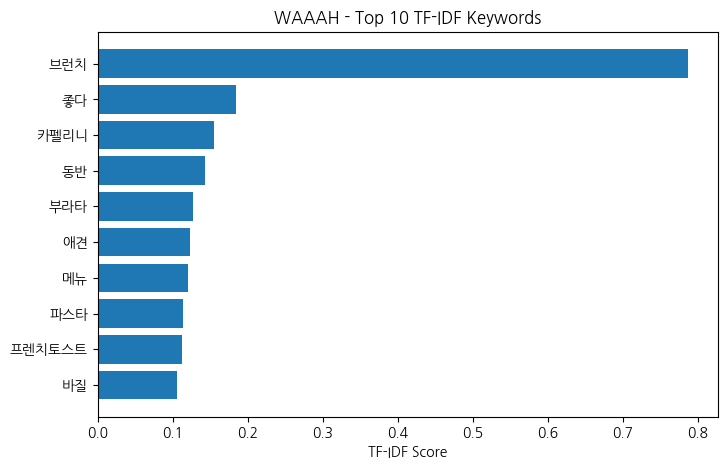

In [25]:
plt.figure(figsize=(8, 5))

plt.barh(
    selected_words[::-1],
    selected_scores[::-1]
)

plt.title(
    f'{selected_cafe} - Top 10 TF-IDF Keywords'
)

plt.xlabel('TF-IDF Score')

plt.show()